In [14]:
# c. solve with L-BFGS-B and print results
print('Solving for Complements:')
sol_bfgs_comp = model_comp.solve(do_print=True)
print(f's1: {sol_bfgs_comp.s1:.4f}, w: {sol_bfgs_comp.w:.4f}, s2: {sol_bfgs_comp.s2:.4f}, s3: {sol_bfgs_comp.s3:.4f}, utility: {sol_bfgs_comp.u:.4f}')

print('\\nSolving for Substitutes:')
sol_bfgs_sub = model_sub.solve(do_print=True)
print(f's1: {sol_bfgs_sub.s1:.4f}, w: {sol_bfgs_sub.w:.4f}, s2: {sol_bfgs_sub.s2:.4f}, s3: {sol_bfgs_sub.s3:.4f}, utility: {sol_bfgs_sub.u:.4f}')

Solving for Complements:
s1: 0.5356, w: 0.4395, s2: 0.2041, s3: 0.2603, utility: 3.4017
\nSolving for Substitutes:
s1: 0.5382, w: 0.6923, s2: 0.3197, s3: 0.1421, utility: 3.4851


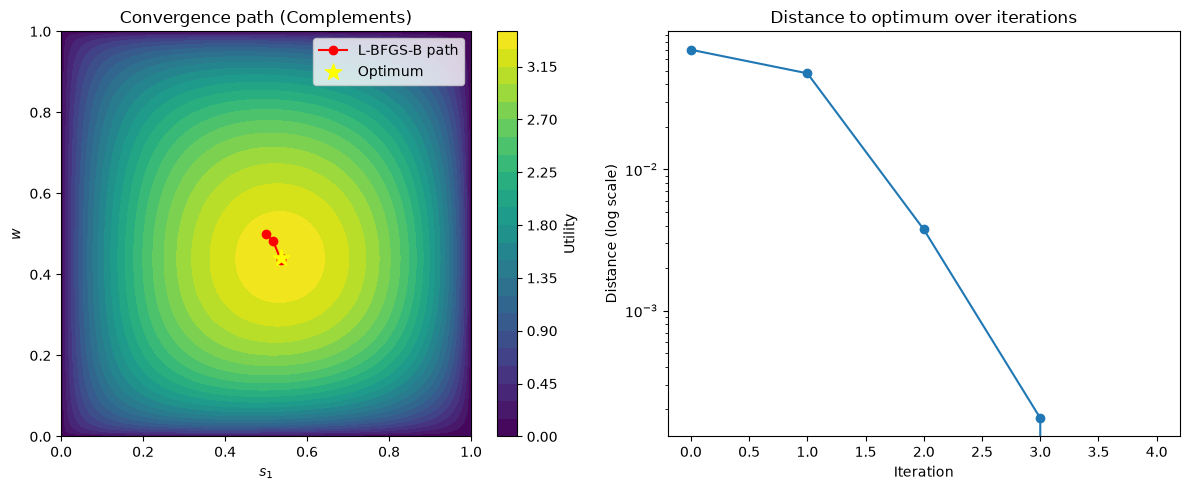

In [15]:
# d. plot convergence path
# i. setup figure
fig = plt.figure(figsize=(12,5))

# ii. Complements: path on top of contour
ax_left = fig.add_subplot(1, 2, 1)

# Note: This assumes you have already run the grid search (solve_grid) 
# and stored the result in 'sol_grid_comp' for the contour plot.
# If not, run it first: sol_grid_comp = model_comp.solve_grid()

cs = ax_left.contourf(sol_comp.s1_grid, sol_comp.w_grid, sol_comp.u_grid, levels=30)
fig.colorbar(cs, ax=ax_left, label='Utility')

# Extract path
path_s1 = [p[0] for p in sol_bfgs_comp.path]
path_w = [p[1] for p in sol_bfgs_comp.path]

# Plot path
ax_left.plot(path_s1, path_w, '-o', color='red', label='L-BFGS-B path')
ax_left.scatter(sol_bfgs_comp.s1, sol_bfgs_comp.w, marker='*', s=150, color='yellow', label='Optimum', zorder=5)

ax_left.set_title('Convergence path (Complements)')
ax_left.set_xlabel('$s_1$')
ax_left.set_ylabel('$w$')
ax_left.legend()

# iii. Complements: distance to optimum over iterations
ax_right = fig.add_subplot(1, 2, 2)

# Calculate distance for each step
distances = [np.sqrt((p[0] - sol_bfgs_comp.s1)**2 + (p[1] - sol_bfgs_comp.w)**2) for p in sol_bfgs_comp.path]
iterations = np.arange(len(distances))

ax_right.plot(iterations, distances, '-o')
ax_right.set_yscale('log')
ax_right.set_title('Distance to optimum over iterations')
ax_right.set_xlabel('Iteration')
ax_right.set_ylabel('Distance (log scale)')

plt.tight_layout()
plt.show()

# Repeat plotting block 'd' for Substitutes (using sol_bfgs_sub and sol_grid_sub) if desired.

In [16]:
# e. test different starting points
starting_points = [
    [0.5, 0.5], 
    [0.01, 0.01], 
    [0.01, 0.99], 
    [0.99, 0.01], 
    [0.99, 0.99],
    [0.2, 0.8]
]

print("Testing starting points for Complements:")
for s0 in starting_points:
    sol = model_comp.solve(s0=s0, do_print=False)
    # The solver might fail, so we extract safely
    try:
        s1_res, w_res = sol.res.x
        n_iter = sol.res.nit
        success = sol.res.success
    except AttributeError:
        # Fallback if res is not populated on failure
        s1_res, w_res, n_iter, success = np.nan, np.nan, np.nan, False
        
    print(f"s0: {s0} -> s1: {s1_res:.4f}, w: {w_res:.4f}, iter: {n_iter}, success: {success}")

Testing starting points for Complements:
s0: [0.5, 0.5] -> s1: 0.5356, w: 0.4395, iter: 4, success: True
s0: [0.01, 0.01] -> s1: 0.5356, w: 0.4395, iter: 6, success: True
s0: [0.01, 0.99] -> s1: 0.5356, w: 0.4395, iter: 7, success: True
s0: [0.99, 0.01] -> s1: 0.5356, w: 0.4395, iter: 6, success: True
s0: [0.99, 0.99] -> s1: 0.5356, w: 0.4395, iter: 5, success: True
s0: [0.2, 0.8] -> s1: 0.5356, w: 0.4395, iter: 6, success: True


In [17]:
# f. test different tolerances (ftol and gtol)
ftols = [1e-4, 1e-8, 1e-12, 1e-16]
gtols = [1e-2, 1e-5, 1e-8, 1e-12]

print("Testing tolerances for Complements:")
print(f"{'ftol':<10} | {'gtol':<10} | {'s1':<8} | {'w':<8} | {'utility':<10} | {'evals':<6}")
print("-" * 65)

for ftol in ftols:
    for gtol in gtols:
        sol = model_comp.solve(options={'ftol': ftol, 'gtol': gtol}, do_print=False)
        # Extract safely
        try:
             s1_res, w_res = sol.res.x
             u_res = -sol.res.fun
             n_evals = sol.res.nfev
        except AttributeError:
             s1_res, w_res, u_res, n_evals = np.nan, np.nan, np.nan, np.nan
        print(f"{ftol:<10} | {gtol:<10} | {s1_res:.4f}   | {w_res:.4f}   | {u_res:.6f}   | {n_evals:<6}")

Testing tolerances for Complements:
ftol       | gtol       | s1       | w        | utility    | evals 
-----------------------------------------------------------------
0.0001     | 0.01       | 0.5356   | 0.4397   | 3.401680   | 15    
0.0001     | 1e-05      | 0.5356   | 0.4397   | 3.401680   | 15    
0.0001     | 1e-08      | 0.5356   | 0.4397   | 3.401680   | 15    
0.0001     | 1e-12      | 0.5356   | 0.4397   | 3.401680   | 15    
1e-08      | 0.01       | 0.5356   | 0.4397   | 3.401680   | 15    
1e-08      | 1e-05      | 0.5356   | 0.4395   | 3.401680   | 18    
1e-08      | 1e-08      | 0.5356   | 0.4395   | 3.401680   | 21    
1e-08      | 1e-12      | 0.5356   | 0.4395   | 3.401680   | 21    
1e-12      | 0.01       | 0.5356   | 0.4397   | 3.401680   | 15    
1e-12      | 1e-05      | 0.5356   | 0.4395   | 3.401680   | 18    
1e-12      | 1e-08      | 0.5356   | 0.4395   | 3.401680   | 21    
1e-12      | 1e-12      | 0.5356   | 0.4395   | 3.401680   | 21    
1e-16      | 0